In [169]:
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import numpy as np
import math

In [170]:
# Replace the keys in this dicitonnary to match the names of the PREVis subscales columns in your data.set
# Each of these 4 columns should contain the average of the subscale's ratings for each participant (row).
subscales = ['Understand', 'Layout', 'DataRead', 'DataFeat']
colors = ['#4ba1bc', '#839e49', '#a87c9f', '#e08095']

# Visualizations
visualizations = {
    "Matrix": {
        "label": "Matrix View",
    },
    "SimilarityView": {
        "label": "Similarity View",
    },
}
visualizations_keys = list(visualizations.keys())

Creating Matrix View visualization...


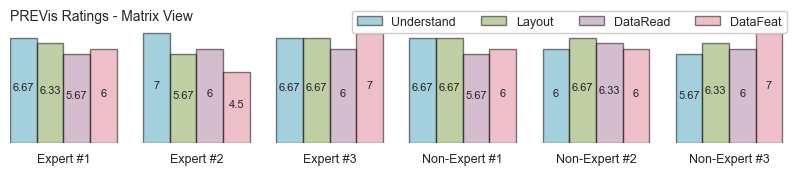

Creating Similarity View visualization...


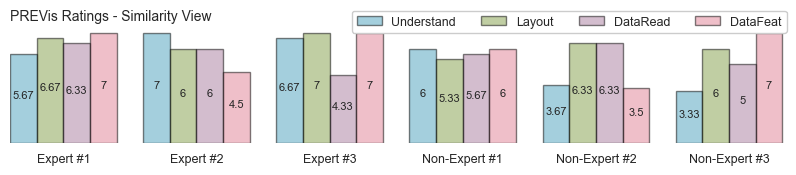

In [ ]:
# Style
sns.set_style("whitegrid")

# Load data
df = pd.read_csv('previs_scores_averages.csv')

# Variables
num_subscales = len(subscales)
num_participants = df['PID'].nunique()
w = 0.1  # smaller bar width for compactness

# Adjusted spacing between participants
first_tick = 0.0
gap = num_subscales * w + 0.1  # reduced gap
x = np.array([first_tick + i * gap for i in range(num_participants)])

# Plot
for visualization_key in visualizations_keys:
    visualization = visualizations[visualization_key]
    print(f"Creating {visualization['label']} visualization...")

    df_vis = df[df['Visualization'] == visualization_key].reset_index(drop=True)

    fig, ax = plt.subplots(1, 1, figsize=(10, 1.5))  # reduced height
    
    # Remove all borders (spines)
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    # Show only horizontal grid lines
    ax.grid(axis='y', linestyle='', alpha=0.5)
    ax.grid(axis='x', linestyle='', alpha=0.5)
    
    # Hide y-axis completely
    ax.yaxis.set_visible(False)  # hides ticks and labels
    
    bars = []

    for i, subscale in enumerate(subscales):
        bar_positions = x + (i - num_subscales / 2 + 0.5) * w
        heights = df_vis[subscale].values

        bars.append(
            ax.bar(
                bar_positions,
                heights,
                width=w,
                color=colors[i],
                align='center',
                edgecolor='black',
                linewidth=1.0,
                alpha=0.5
            )
        )

    ax.set_ylabel(f"PREVis subscale ratings for {visualization['label']}", fontsize=10)
    # ax.set_xlabel('Participants', fontsize=10)
    fig.text(0.125, 1, f"PREVis Ratings - {visualization['label']}", fontsize=10, ha='left', va='top')
    
    ax.set_xticks(x)
    ax.set_xticklabels(df_vis['ParticipantLabel'], fontsize=9)
    ax.tick_params(axis='y', labelsize=9)

    for bar_group in bars:
        ax.bar_label(bar_group, padding=2, label_type='center', fontsize=8)

    ax.legend(
        bars,
        subscales,
        ncol=4,
        loc='upper right',
        bbox_to_anchor=(1.01, 1.25),  # move it higher
        framealpha=1,
        fontsize=9
    )
    
    # Tightly control horizontal space
    ax.set_xlim(x[0] - 2*w, x[-1] + 2*w + 0.01)

    # Save the figure with minimal whitespace
    fig.savefig(f"previs_fig_{visualization_key.lower()}.png", dpi=300, bbox_inches='tight')

    # Optional: show saved figure in the same tight format
    plt.show()

Creating Matrix View visualization...


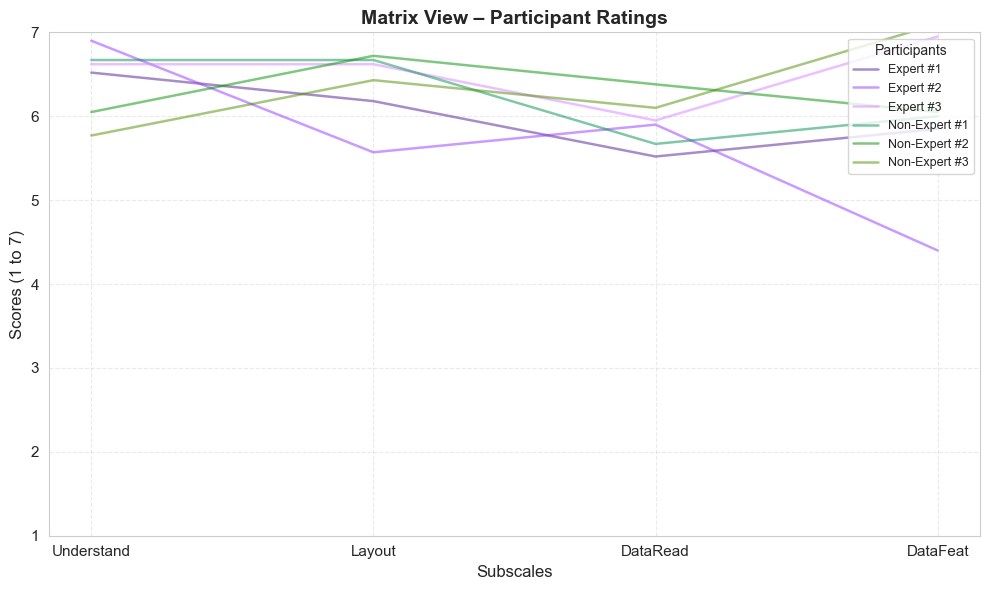

Creating Similarity View visualization...


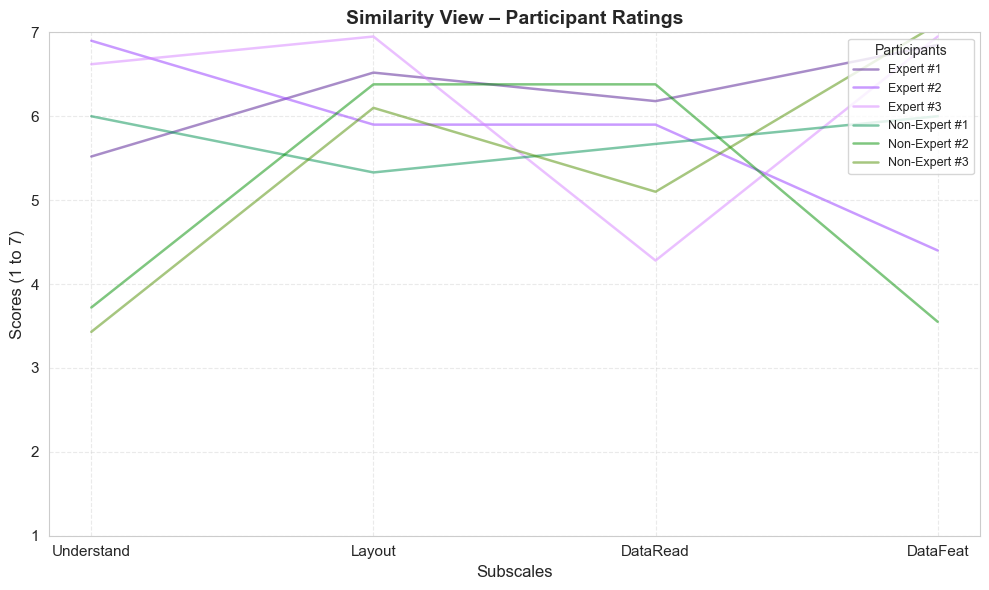

In [172]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D

# Load data
df = pd.read_csv('previs_scores_averages.csv')

x_positions = list(range(1, len(subscales) + 1))  # [1, 2, 3, 4]

# Optional: cycle through colors if many participants
# colors = cm.get_cmap('tab10')  # you could try 'Set2', 'Dark2', 'tab20' too
participant_colors = ['#531b93', '#9437ff', '#d783ff', '#009051', '#008f00', '#4f8f00']

# Plot
for visualization_key in visualizations_keys:
    visualization = visualizations[visualization_key]
    print(f"Creating {visualization['label']} visualization...")

    df_vis = df[df['Visualization'] == visualization_key].reset_index(drop=True)
    
    plt.figure(figsize=(10, 6))

    for i, row in df_vis.iterrows():
        vertical_offset = 0.05 * (i - len(df_vis) / 2)
        scores = [row[sub] + vertical_offset for sub in subscales]
        color = participant_colors[i]
        plt.plot(
            x_positions, scores,
            marker='',
            markersize=6,
            linewidth=1.8,
            color=color,
            alpha=0.5,
            label=row['ParticipantLabel']
        )

    # Axis and labels
    plt.xticks(ticks=x_positions, labels=subscales, fontsize=11)
    plt.yticks(fontsize=11)
    plt.xlabel('Subscales', fontsize=12)
    plt.ylabel('Scores (1 to 7)', fontsize=12)
    plt.ylim(1, 7)
    
    # Title and grid
    plt.title(f"{visualization['label']} – Participant Ratings", fontsize=14, weight='bold')
    plt.grid(True, linestyle='--', alpha=0.4)

    # Optional legend
    if len(df_vis) <= 10:
        plt.legend(title='Participants', fontsize=9, title_fontsize=10, loc='upper right')
    
    plt.tight_layout()
    plt.show()

In [173]:
# Create parallel plot
plt.figure(figsize=(8, 6))
parallel_plot = sns.lineplot(data=normalized_data.transpose(),
                             dashes=False,
                             markers=True,
                             markersize=8)

# Add title
plt.title('Parallel Plot \nAverage GDP, Life Expectancy, and Population by Continent')

# Remove y-axis ticks and tick labels
plt.yticks([])

# Add legend
plt.legend(title='Continent',
           bbox_to_anchor=(1, 1), # Shift legend to the right
          )

# Display the chart
plt.show()

NameError: name 'normalized_data' is not defined

<Figure size 800x600 with 0 Axes>